# 4 Initial System

asd

In [34]:
# Relevant imports
from pathlib import Path
import numpy as np
from collections import defaultdict, Counter
import re
import csv
from datetime import datetime
import matplotlib.pyplot as plt

# Setup initial filepaths
ROOT = Path("project_release")

TRAIN_CORPUS_PATH = ROOT / "Amazon_products" / "train" / "train_corpus.txt"
TEST_CORPUS_PATH = ROOT / "Amazon_products" / "test" / "test_corpus.txt"

CLASSES_PATH = ROOT / "Amazon_products" / "classes.txt"
HIERARCHY_PATH = ROOT / "Amazon_products" / "class_hierarchy.txt"
KEYWORDS_PATH = ROOT / "Amazon_products" / "class_related_keywords.txt"

In [35]:
# Step 1: Load and sanitize class names
classes = []
with open(CLASSES_PATH, "r", encoding="utf8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            idx, name = parts
            classes.append(name.strip().lower())

idx_to_class = {i: name for i, name in enumerate(classes)}
class_to_idx = {name: i for i, name in enumerate(classes)}

# Step 2: Load and Sanitize Hierarchy
children_map = defaultdict(list)
parents_map = defaultdict(list)

with open(HIERARCHY_PATH, "r", encoding="utf8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            parent_idx, child_idx = map(int, parts)
            children_map[parent_idx].append(child_idx)
            parents_map[child_idx].append(parent_idx)

# Step 3: Load class-related keywords
class_keywords = {}

with open(KEYWORDS_PATH, "r", encoding="utf8") as f:
    for line in f:
        parts = line.strip().split(":")
        cls = parts[0].strip().lower()
        kws = parts[1] if len(parts) > 1 else ""
        class_keywords[cls] = [k.strip().lower() for k in kws.split(",") if k]

# Step 4: Load and Preprocess Corpora
def load_corpus_plaintext(path):
    with open(path, "r", encoding="utf8") as f:
        return {i: line.strip() for i, line in enumerate(f)}

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_pid2text = load_corpus_plaintext(TRAIN_CORPUS_PATH)
test_pid2text = load_corpus_plaintext(TEST_CORPUS_PATH)

train_pid2text = {pid: preprocess_text(text) for pid, text in train_pid2text.items()}
test_pid2text = {pid: preprocess_text(text) for pid, text in test_pid2text.items()}

def dict2list(id2text):
    ids = list(id2text.keys())
    texts = [id2text[i] for i in ids]
    return ids, texts

train_ids, train_texts = dict2list(train_pid2text)
test_ids, test_texts = dict2list(test_pid2text)

# 2.b. Keyword Matching

This proof-of-concept generates silver labels using class-related keywords and the hierarchical taxonomy of product categories. Each review is scanned for any matching keywords, and when a match occurs, the corresponding class is marked as relevant. To respect the hierarchy, selecting a child class automatically includes its parent classes. If a keyword belongs to multiple classes, all relevant classes are assigned in this initial test, even though this may introduce noise. The resulting mapping provides a list of classes per review, forming the silver labels that serve as initial training targets for the model. This simple and interpretable approach lays the groundwork for later refinements with more advanced methods.


In [ ]:
# Step 1: Extract only relevant keywords from each review
# Reviews without keywords are left unassigned, and some may be ambiguous.

review_keywords = {}

all_class_keywords = set()
for kws in class_keywords.values():
    all_class_keywords.update(kws)

for pid, text in train_pid2text.items():
    tokens = set(text.split())
    keywords_in_review = tokens.intersection(all_class_keywords)
    review_keywords[pid] = keywords_in_review

for pid in list(review_keywords.keys())[:50]:
    print(f"Review {pid} -> Keywords: {sorted(list(review_keywords[pid]))}")


Review 0 -> Keywords: ['relaxation']
Review 1 -> Keywords: ['chocolate', 'natural']
Review 2 -> Keywords: ['butter', 'coffee', 'fresh', 'vegetables']
Review 3 -> Keywords: []
Review 4 -> Keywords: ['homemade']
Review 5 -> Keywords: []
Review 6 -> Keywords: []
Review 7 -> Keywords: []
Review 8 -> Keywords: []
Review 9 -> Keywords: ['socks']
Review 10 -> Keywords: ['balance']
Review 11 -> Keywords: ['coffee', 'healthy', 'milk', 'natural']
Review 12 -> Keywords: []
Review 13 -> Keywords: []
Review 14 -> Keywords: ['mirror', 'toys']
Review 15 -> Keywords: ['tea']
Review 16 -> Keywords: ['coordination', 'shapes']
Review 17 -> Keywords: ['conditioner', 'moisturizing', 'shampoo']
Review 18 -> Keywords: []
Review 19 -> Keywords: ['california', 'wings']
Review 20 -> Keywords: []
Review 21 -> Keywords: []
Review 22 -> Keywords: ['infant']
Review 23 -> Keywords: ['cheese', 'educational', 'games', 'performance']
Review 24 -> Keywords: []
Review 25 -> Keywords: ['adorable']
Review 26 -> Keywords: [

In [ ]:
# Step 2: Map review keywords to classes using a reverse lookup from keyword to class.

keyword_to_classes = defaultdict(list)
for cls, kws in class_keywords.items():
    for kw in kws:
        keyword_to_classes[kw].append(cls)

# Extract keywords present in each review based on the class keyword list
review_to_keywords = {}
for pid, text in train_pid2text.items():
    words = set(text.split())
    kws_in_review = [w for w in words if w in keyword_to_classes]
    review_to_keywords[pid] = kws_in_review

# Assign each review to all classes corresponding to its keywords
review_to_classes = defaultdict(list)
for pid, keywords in review_to_keywords.items():
    matched_classes = set()
    for kw in keywords:
        matched_classes.update(keyword_to_classes[kw])
    review_to_classes[pid] = list(matched_classes)

for pid in range(10):
    print(f"Review {pid} -> Classes: {review_to_classes[pid]}")

Review 0 -> Classes: ['bubble_bath', 'aromatherapy']
Review 1 -> Classes: ['fruit_leather', 'trail_mix']
Review 2 -> Classes: ['fruit', 'beverages', 'popcorn', 'produce', 'dairy_eggs', 'dinners']
Review 3 -> Classes: []
Review 4 -> Classes: ['fudge', 'fruit_leather', 'salsas', 'stuffing']
Review 5 -> Classes: []
Review 6 -> Classes: []
Review 7 -> Classes: []
Review 8 -> Classes: []
Review 9 -> Classes: ['apparel_accessories']


In [ ]:
# Count how many reviews contain at least one keyword
num_with_keywords = sum(1 for kws in review_to_keywords.values() if len(kws) > 0)
total_reviews = len(review_to_keywords)

print(f"Reviews with keywords: {num_with_keywords}/{total_reviews}")
print(f"Percentage: {num_with_keywords / total_reviews * 100:.2f}%")

Reviews with keywords: 19500/29487
Percentage: 66.13%


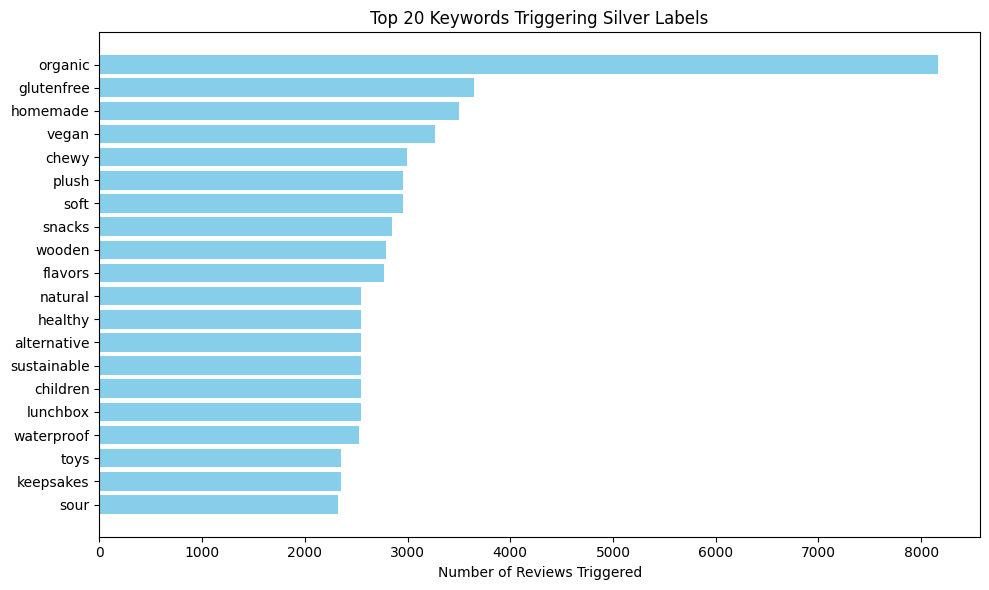

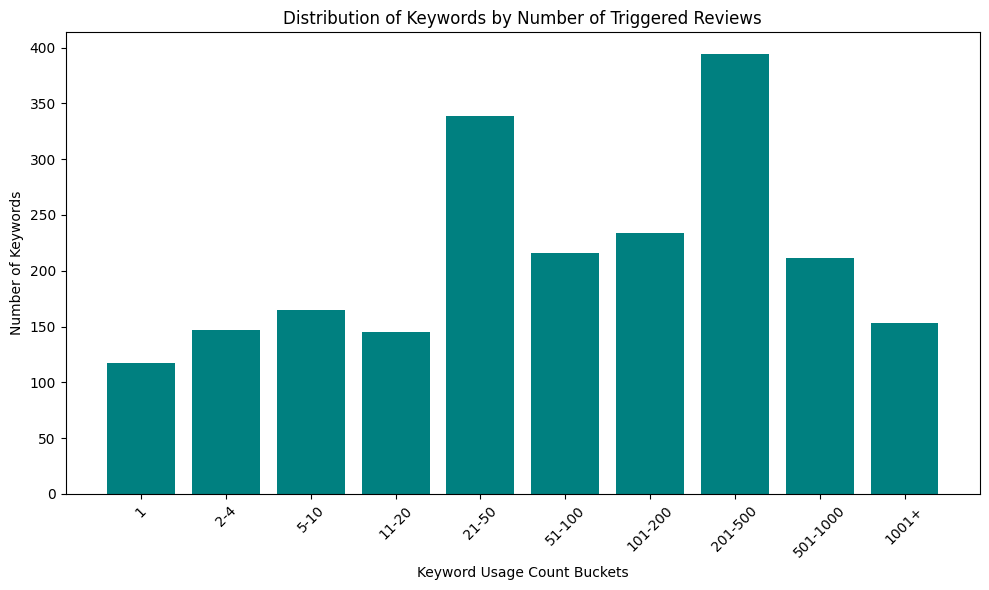

In [ ]:
"""
Which keywords triggered the most class assignments?
Which keywords triggered the fewest?
"""

# Count how many times each keyword triggered a class
keyword_counter = Counter()

for pid, classes in review_to_classes.items():
    for cls in classes:
        for kw, cls_list in keyword_to_classes.items():
            if cls in cls_list:
                keyword_counter[kw] += 1

# Visualize the 20 keywords that triggered the most silver labels
top_keywords = keyword_counter.most_common(20)
top_keys, top_counts = zip(*top_keywords)

plt.figure(figsize=(10,6))
plt.barh(top_keys[::-1], top_counts[::-1], color='skyblue')
plt.xlabel("Number of Reviews Triggered")
plt.title("Top 20 Keywords Triggering Silver Labels")
plt.tight_layout()
plt.show()

# Visualize the distribution of keyword usage across all reviews using defined buckets
bins = [
    (1,1),
    (2,4),
    (5,10),
    (11,20),
    (21,50),
    (51,100),
    (101,200),
    (201,500),
    (501,1000),
    (1001,float('inf'))
]
bin_labels = ["1", "2-4", "5-10", "11-20", "21-50", "51-100", "101-200", "201-500", "501-1000", "1001+"]

bin_counts = {label:0 for label in bin_labels}
for kw, count in keyword_counter.items():
    for (low, high), label in zip(bins, bin_labels):
        if low <= count <= high:
            bin_counts[label] += 1
            break
        
plt.figure(figsize=(10,6))
plt.bar(bin_counts.keys(), bin_counts.values(), color='teal')
plt.xlabel("Keyword Usage Count Buckets")
plt.ylabel("Number of Keywords")
plt.title("Distribution of Keywords by Number of Triggered Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:

# Step 3: Save silver labels to a timestamped file for reuse
# silver_labels_METHOD_date
METHOD = "keyword_matching"

date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
SILVER_LABELS_PATH = f"silver_labels_{METHOD}_{date_str}.csv"

with open(SILVER_LABELS_PATH, "w", newline="", encoding="utf8") as f:
    writer = csv.writer(f)
    writer.writerow(["review_id", "classes"])
    for pid, cls_list in review_to_classes.items():
        writer.writerow([pid, ",".join(cls_list)])

print(f"Silver labels saved to {SILVER_LABELS_PATH}")

Silver labels saved to silver_labels_keyword_matching_20251121_164212.csv


# 2.c. Embedding Similarity

TBD 

# 2.d. Hybrid Approach

TBD

# 2.e. Hybrid Approach #2 (Featuring LLM)

TBD

# 2.f. Silver Label Evaluation

This section presents key methods for assessing the quality and coverage of the generated silver labels.
We aim to understand how well the labeling process captured relevant classes for the training reviews and where gaps or ambiguities remain.

In [ ]:
# Benchmark: Count reviews that were not assigned any silver labels

total_reviews = len(train_pid2text)
unlabeled_reviews = [pid for pid in train_pid2text if pid not in review_to_classes or not review_to_classes[pid]]
num_unlabeled = len(unlabeled_reviews)

print("Total reviews:", total_reviews)
print("Unlabeled reviews:", num_unlabeled)
print("Percentage unlabeled:", 100 * num_unlabeled / total_reviews)


Total reviews: 29487
Unlabeled reviews: 9987
Percentage unlabeled: 33.869162681859805


In [ ]:
# Identify reviews linked to multiple, separate hierarchies
# Reviews that span different branches of the class taxonomy may introduce noise

def get_ancestors(cls_idx, parents_map):
    ancestors = set()
    stack = [cls_idx]
    while stack:
        node = stack.pop()
        if node in parents_map:
            for p in parents_map[node]:
                if p not in ancestors:
                    ancestors.add(p)
                    stack.append(p)
    return ancestors

multi_hierarchy_count = 0
for pid, cls_list in review_to_classes.items():
    if len(cls_list) <= 1:
        continue
    cls_indices = [class_to_idx[c] for c in cls_list if c in class_to_idx]
    families = [get_ancestors(idx, parents_map) | {idx} for idx in cls_indices]

    intersection = set.intersection(*families)
    if len(intersection) == 0:
        multi_hierarchy_count += 1

print("Reviews linked to multiple hierarchies:", multi_hierarchy_count)


Reviews linked to multiple hierarchies: 8690


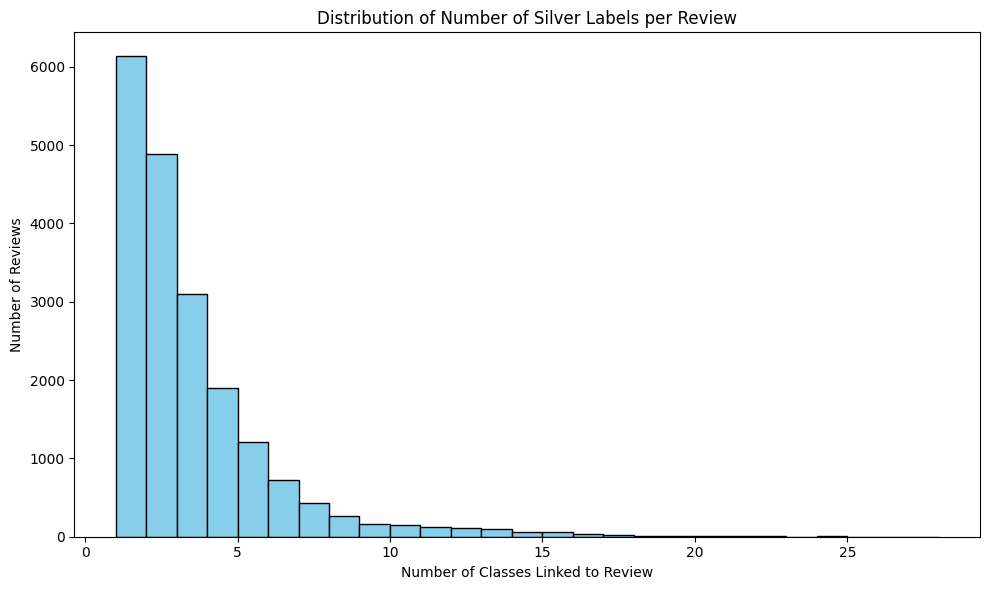

In [ ]:
# Distribution of number of classes linked per review
# Histogram shows, for each review, how many classes were assigned as silver labels.
# More can signify noise

linked_counts = [len(cls_list) for cls_list in review_to_classes.values()]
plt.figure(figsize=(10,6))
plt.hist(linked_counts, bins=range(1, max(linked_counts)+2), color='skyblue', edgecolor='black')
plt.xlabel("Number of Classes Linked to Review")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Number of Silver Labels per Review")
plt.tight_layout()
plt.show()


In [ ]:
# Count classes that remain unlinked
# Highlights gaps in coverage of the silver-labeling process.

all_classes = set(classes)
linked_classes = set(cls for cls_list in review_to_classes.values() for cls in cls_list)
unlinked_classes = all_classes - linked_classes

print("Total classes:", len(all_classes))
print("Unlinked classes:", len(unlinked_classes))
print("Percentage unlinked:", 100 * len(unlinked_classes) / len(all_classes))


Total classes: 531
Unlinked classes: 280
Percentage unlinked: 52.73069679849341
